<a href="https://colab.research.google.com/github/nany114as-dotcom/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?



In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [ ]:
# cantidad de nulos para users

print("Cantidad de valores nulos")
print(users.isna().sum())
print("Proporción de valores nulos")
print(users.isna().mean())


Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("# Cantidad de valores nulos")
print(usage.isna().sum())
print("# Proporción de valores nulos")
print(usage.isna().mean())

# Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
# Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


#### Diagnóstico de Valores Nulos
- **users['city']** (11.7% de nulos): Imputaré con la etiqueta 'Desconocida' para investigar después el origen del fallo y no perder la información de consumo de estos usuarios (rango 5%-30%).
- **users['churn_date']** (88.3% de nulos): Ignoraré, sin cambios, ya que es un nulo estructural que justifica de forma correcta que el cliente sigue activo en la empresa (excepción a la regla del >80%).
- **usage['date']** (0.12% de nulos): Mantendré estas 50 filas como nulos para no perder el registro de consumo de estos usuarios, optando por filtrarlos con .dropna(subset=['date']) únicamente cuando se realicen análisis temporales.
- **usage['duration']** (55.2%) y **length** (44.7%): Mantendré intactos como nulos estructurales complementarios, dado que una llamada no genera caracteres de texto y un mensaje no consume minutos.

In [ ]:


# explorar columnas numéricas de users
users[['user_id', 'age']].describe()



,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Muestra un rango secuencial e íntegro de IDs únicos desde el 10000 al 13999 para los 4000 usuarios sin valores duplicados ni anomalías estadísticas.
- La columna `age`: Presenta un valor mínimo inválido de -999, que actúa claramente como un valor centinela para registros faltantes. Esto distorsiona la media real y genera una desviación estándar de 123, la cual es matemáticamente imposible para edades humanas, requiere limpieza en los siguientes pasos.

In [ ]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: Muestran una distribución consistente y esperada. Su conteo de 40,000 registros confirma la ausencia total de valores nulos. El id cubre secuencialmente desde el 1 al 40,000, mientras que los user_id se mantienen estrictamente dentro del rango correcto de clientes (10000 a 13999), lo que valida la coherencia entre conjuntos de datos.
- Las columnas `duration` y `length`: Presentan conteos menores a 40,000 debido a que la tabla unifica dos tipos de eventos (llamadas y mensajes), dejando valores nulos en la actividad no correspondiente. Los mínimos de 0.0 reflejan llamadas no contestadas y registros vacíos, lo cual es habitual. Sin embargo, la columna length registra un valor máximo atípico (outlier) de 1,490 caracteres que supera por mucho el estándar de un SMS tradicional y distorsiona la dispersión.

In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- Conteo de valores para {col} ---")
    print(users[col].value_counts(dropna=False).head(10))




--- Conteo de valores para city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- Conteo de valores para plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`: Presenta problemas de calidad de datos con 469 valores nulos (NaN) y 96 registros con el signo "?" actuando como valor centinela para datos desconocidos. Las ciudades con mayor concentración de usuarios son Bogotá, CDMX y Medellín. Requiere unificación y limpieza.
- La columna `plan`: Se encuentra completamente limpia y consistente, distribuyendo a los 4,000 usuarios sin registros nulos ni anomalías entre dos categorías exclusivas: Basico (2,595) y Premium (1,405

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código


text    22092
call    17908
Name: type, dtype: int64

- La columna `type`: Se encuentra completamente limpia y consistente. Clasifica la totalidad de los 40,000 registros sin presentar valores nulos ni categorías extrañas, dividiéndose exclusivamente en text (22,092) y call (17,908). Esto confirma que el dataset registra eventos individuales de consumo.


#### Diagnóstico de Calidad de Datos y Plan de Acción
Columna `age` (Tabla users):
El valor centinela -999
**Acción:** Reemplazar el -999 a nulo real (NaN) para limpiar la estadística descriptiva e identificar el volumen de faltantes, procediendo inmediatamente a imputar directamente con la mediana.

Columna `city` (Tabla users):
Coexistencia de 469 nulos (NaN) y 96 signos de interrogación (?)
**Acción:** Unificar la columna convirtiendo los "?" a nulos reales y rellenar el total de faltantes con la etiqueta "NaN" para mantener la integridad en el análisis geográfico.



Columnas `duration` y `length` (Tabla usage):
Los mínimos de 0.0 en llamadas son válidos (llamadas perdidas), pero la columna `length` presenta un outlier severo de 1,490 caracteres en un SMS.
**Acción:** Mantener los registros 0.0 por su valor de negocio, el outlier de 1,490 en length se evaluará y filtrará usando el método IQR.





In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`: Observo una distribución mayoritaria y consistente entre los años 2022 y 2024 (aproximadamente 1,310 - 1,330 registros por año). Sin embargo, se detectó una anomalía con 40 registros indexados en el año 2026, lo cual representa una fecha futura imposible dado que el límite del dataset es 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False))

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`: Concentración masiva de 39,950 registros en 2024. La conversión limpia identificó 50 valores nulos (NaN) que venían corruptos o con errores de formato desde el origen.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? Sí. En la columna reg_date (users) se detectaron 40 registros con el año 2026, lo cual es una fecha futura imposible ya que el dataset solo contiene datos hasta 2024. Por otro lado, en date (usage) la conversión identificó 50 valores corruptos que se transformaron en NaN.
- ¿Qué harías con ellas?
Para el año 2026 en `reg_date`: Convertir esos 40 registros a nulos (NaN) para preservar los datos del usuario (edad, plan, ciudad) sin distorsionar las métricas de antigüedad.
Para los NaN en `date`(usage): Mantenerlos como nulos (NaN/NaT). Conservar estas 50 filas permite proteger los datos de consumo (duration y length) para no subestimar el uso total de la red, optando por excluirlos únicamente cuando se realicen análisis estrictamente mensuales.
  

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:


# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))



Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT
# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))



2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


In [ ]:

# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isnull().sum()))
print("\nTotal de registros por tipo:")
print(usage['type'].value_counts())


type
call        0
text    22076
Name: duration, dtype: int64

Total de registros por tipo:
text    22092
call    17908
Name: type, dtype: int64


In [ ]:

# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isnull().sum()))


type
call    17896
text        0
Name: length, dtype: int64


#### Diagnóstico de nulos

El 100% de los nulos de `duration` (22,076 registros) pertenecen de forma exclusiva a filas de tipo text, ya que un mensaje de texto no consume minutos de transmisión.
El 100% de los nulos de length (17,896 registros) ocurren únicamente en filas de tipo call, dado que una llamada de voz no genera caracteres.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()


In [ ]:


# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
columnas_metricas = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_metricas] = user_profile[columnas_metricas].fillna(0).astype(int)
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8


In [ ]:

# Resumen estadístico de las columnas numéricas
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe().T



,count,mean,std,min,25%,50%,75%,max
age,4000.0,48.13600,17.689919,18.0,33.0,48.0,63.0,79.0
cant_mensajes,4000.0,5.52300,2.359738,0.0,4.0,5.0,7.0,17.0
cant_llamadas,4000.0,4.47700,2.145139,0.0,3.0,4.0,6.0,15.0
cant_minutos_llamada,4000.0,22.81225,18.167719,0.0,11.0,19.0,31.0,155.0


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

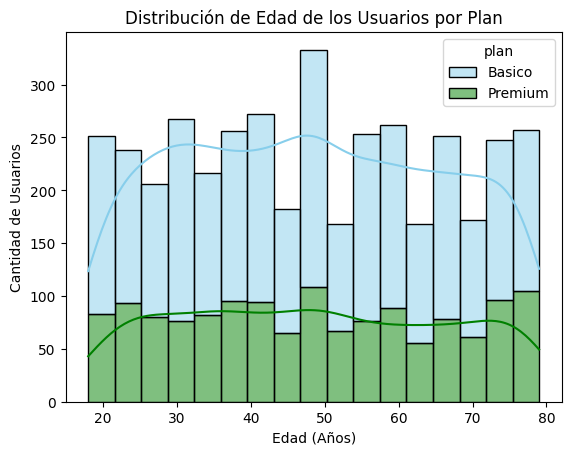

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], multiple='stack', kde=True)
plt.title('Distribución de Edad de los Usuarios por Plan')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- Distribución: Presenta una distribución uniforme y simétrica en general entre los 18 y los 79 años. Aunque las barras muestran pequeñas fluctuaciones naturales de subidas y bajadas a lo largo de las edades, la población se mantiene bastante estable y regular, destacando únicamente un pico máximo de concentración a los 50 años (donde se superan los 320 usuarios) y un descenso más visible en el rango previo a los 60 años (55-59) y cerca de los 70 años.
- Patrón por Plan: No existe ninguna relación aparente entre la edad del usuario y el tipo de plan contratado. La proporción de usuarios con plan Premium (verde) y plan Básico (skyblue) se mantiene notablemente constante en todos los rangos de edad, lo que significa que la edad no es un factor determinante para elegir un plan más costoso en este mercado.

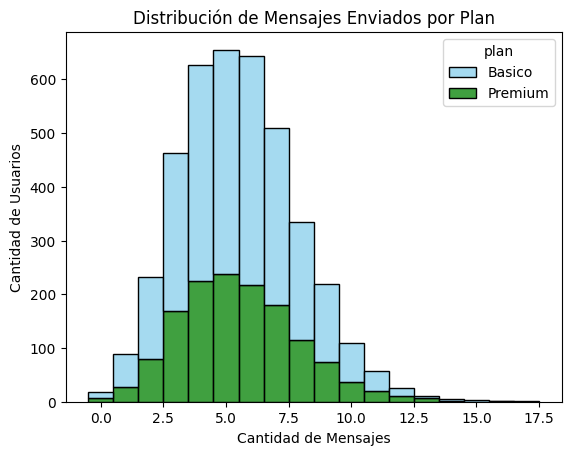

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], multiple='stack', discrete=True)
plt.title('Distribución de Mensajes Enviados por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- Distribución: Presenta una distribución sesgada a la derecha, con una forma acampanada muy clara. El pico máximo de concentración de los usuarios se encuentra entre los 4 y 6 mensajes enviados. A partir de ahí, la cantidad de usuarios disminuye drásticamente a medida que aumenta el volumen de mensajes, dejando una cola delgada hacia los valores más altos (llegando hasta un máximo de 17 mensajes).
- Patrón por Plan: No se observa un comportamiento diferenciado según el plan comercial. Al mirar los colores apilados, tanto las barras del plan Básico (skyblue) como las del Premium (green) suben y bajan exactamente en las mismas proporciones. Esto nos indica que los usuarios Premium no envían más mensajes que los usuarios del plan Básico, ambos grupos usan este servicio de la misma manera.

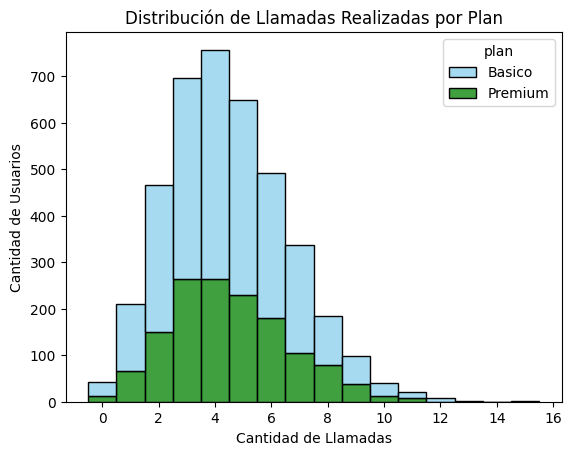

In [ ]:

# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], multiple='stack', discrete=True)
plt.title('Distribución de Llamadas Realizadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights:
- Distribución: Presenta una distribución sesgada a la derecha, con una forma acampanada muy clara. El pico máximo de concentración de los usuarios se encuentra entre las 3 y 5 llamadas realizadas. A partir de ahí, la cantidad de usuarios disminuye de manera progresiva a medida que aumenta el volumen, dejando una cola hacia los valores más altos que se extiende hasta un máximo de 15 o 16 llamadas.
- Patrón por Plan: No se observa un comportamiento diferenciado según el plan comercial. Al mirar las barras apiladas, tanto el plan Básico (azul) como el Premium (verde) siguen la misma tendencia y suben y bajan exactamente en las mismas proporciones. Esto nos indica que los usuarios Premium no realizan más llamadas que los del plan Básico; ambos grupos consumen el servicio de voz de la misma manera.

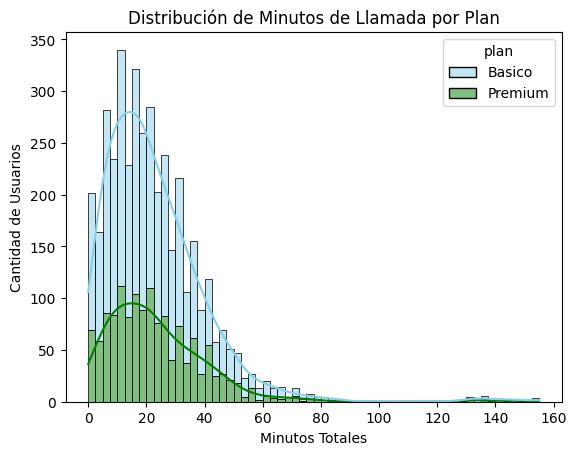

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], multiple='stack', kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos Totales')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- Distribución: Presenta una distribución fuertemente sesgada a la derecha. La gran mayoría de la población se concentra en consumos moderados, con un pico muy claro entre los 10 y los 25 minutos totales de llamada. A partir de los 40 minutos, la cantidad de usuarios disminuye drásticamente, generando una cola muy larga y delgada.
- Patrón por Plan: El comportamiento general de consumo se mantiene muy similar e independiente del plan (la proporción visual de skyblue y green se conserva estable en el bloque principal). Sin embargo, este gráfico hace completamente visible la presencia de valores atípicos (outliers): se observa un pequeño grupo aislado de usuarios con consumos extremos que rompen la normalidad, destacando ese usuario que llega al máximo absoluto de 155 minutos, independientemente de si tiene contratado el plan Básico o Premium.

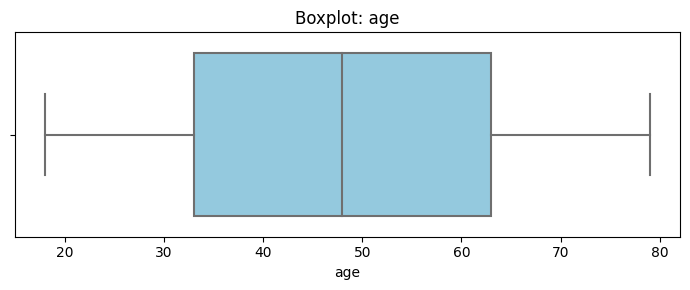

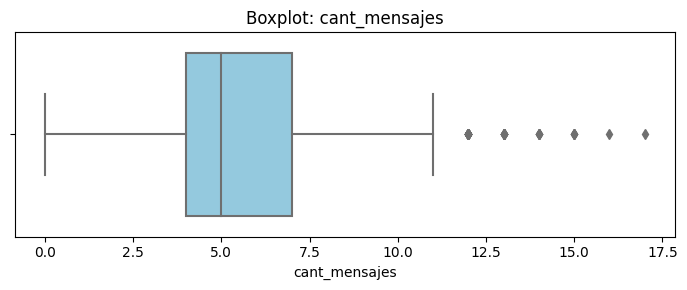

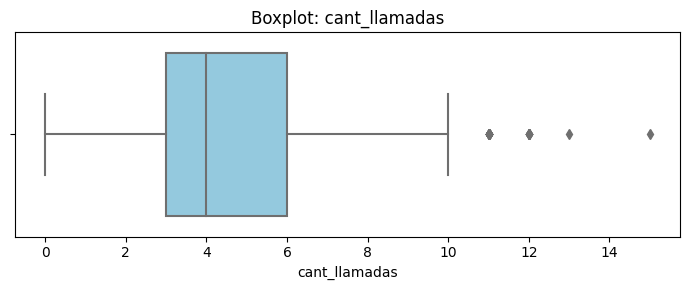

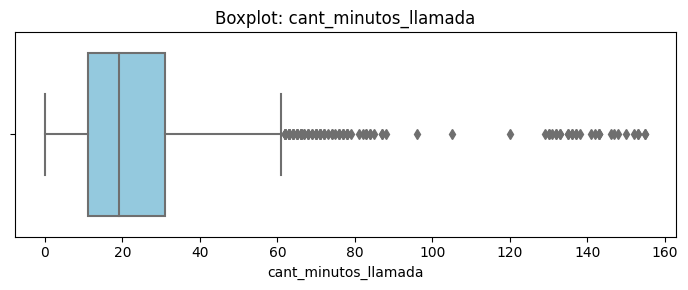

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


💡Insights:
- Age: No presenta outliers. La distribución de edades se mantiene perfectamente contenida dentro de los límites esperados (aproximadamente entre los 18 y los 80 años).
- cant_mensajes: Sí presenta outliers en el extremo superior. Se observan valores atípicos a partir de los 11 mensajes, llegando hasta un máximo de 17 mensajes enviados de forma aislada.
- cant_llamadas: Sí presenta outliers en el extremo superior. Existen usuarios que realizan un volumen atípico de llamadas, situándose por encima de las 10 llamadas y llegando hasta un máximo registrado de 15 llamadas.
- cant_minutos_llamada: Sí presenta una cantidad significativa de outliers en el extremo superior. Los valores atípicos comienzan a partir de los 60 minutos y se extienden en una línea densa con casos extremos que alcanzan los 100, 140 e incluso un máximo de 155 minutos totales.

In [ ]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Variable: {col} -> Límite Superior Matemático: {limite_superior:.2f}")



Variable: cant_mensajes -> Límite Superior Matemático: 11.50
Variable: cant_llamadas -> Límite Superior Matemático: 10.50
Variable: cant_minutos_llamada -> Límite Superior Matemático: 61.00


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,22.812250
std,2.359738,2.145139,18.167719
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.000000
50%,5.000000,4.000000,19.000000
75%,7.000000,6.000000,31.000000
max,17.000000,15.000000,155.000000


💡Insights:
- cant_mensajes: Se decide mantener los outliers. El límite matemático es de 11.50 mensajes, pero el valor máximo real es de 17. Este volumen es perfectamente viable en el uso cotidiano de la aplicación y representa a los usuarios más activos en mensajería.
- cant_llamadas: Se decide mantener los outliers. El límite matemático se fijó en 10.50 llamadas, pero el máximo alcanza las 15. Realizar 15 llamadas en un periodo de facturación o registro es un comportamiento completamente normal para un cliente real.
- cant_minutos_llamada: Se decide mantener los outliers. Aunque el límite matemático es de 61.00 minutos y el máximo se dispara de forma extrema hasta los 155.00 minutos, estos registros pertenecen a clientes con un perfil de consumo pesado. Eliminarlos alteraría artificialmente las métricas reales de uso de red y comportamiento comercial.

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8,Bajo uso


In [ ]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8,Bajo uso,Adulto Mayor


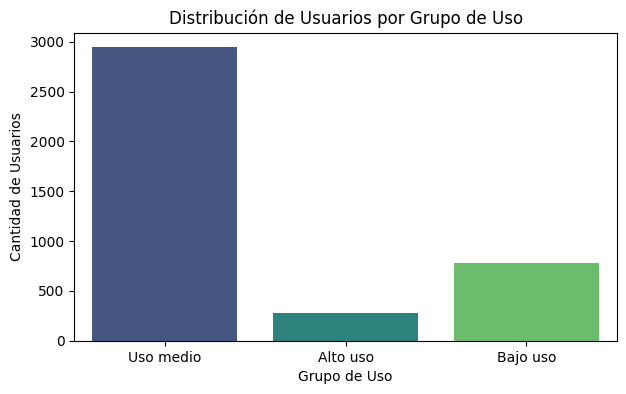

In [ ]:
# Visualización de los segmentos por uso
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

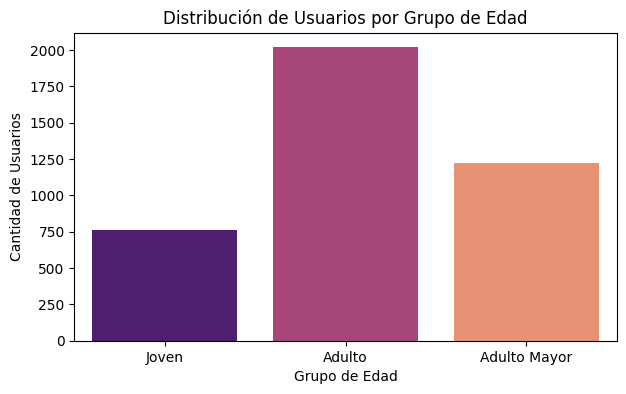

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 4))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Columna `age` ['Edad']: Presentaba un valor mínimo inválido de -999, que actuaba como un valor centinela para registros faltantes. Esto distorsionaba la media real (bajándola a 33.74) y generaba una desviación estándar de 123, la cual era matemáticamente imposible para edades humanas. Este problema afectaba a 55 filas (un 1.38% del dataset de usuarios).
- Columna `city` ['Ciudad']: Registraba problemas de calidad con 469 valores nulos (NaN) y 96 registros con el signo "?" actuando como valor centinela para datos desconocidos. En total, sumaban 565 filas afectadas (un 14.1% de la tabla de usuarios).
- Columna `reg_date` (Fecha de Registro): Aunque la distribución era mayoritaria y consistente entre 2022 y 2024 (aprox. 1,310 - 1,330 registros por año), se detectó una anomalía crítica con 40 registros indexados en el año 2026, lo cual representa una fecha futura imposible dado que el límite del dataset es 2024.
Columna `usage` ['date'] (Fecha de Consumo): Presentaba una concentración masiva de 39,950 registros en 2024, pero contenía un porcentaje marginal de 0.12% de valores nulos (equivalente exactamente a 50 filas) que venían corruptos o con errores de formato desde el origen.
- Columnas `duration` y `length`: Presentaban conteos menores a los 40,000 registros globales debido a nulos estructurales complementarios (las llamadas no generan caracteres de texto y los mensajes no consumen minutos). Asimismo, la columna length registraba un valor máximo outlier de 1,490 caracteres que rompía el estándar de un SMS.
- Columna `usage` [ 'date']: Contenía un porcentaje marginal de 0.12% de valores nulos, lo que equivalía exactamente a 50 filas con la fecha ausente dentro del registro de consumos.
- Columna `churn_date` ['Fecha de Baja']: Presentaba un 88.3% de valores nulos. Sin embargo, se identificó como un nulo estructural correcto que indica que el cliente sigue activo en la empresa, por lo que no requería eliminación.

Durante el diagnóstico de calidad de datos, identificamos y decidimos conservar estratégicamente dos patrones de comportamiento extremo en el dataset de consumo:

- Outliers de Duración en Voz: Usuarios con llamadas que se alejaban drásticamente de la mediana general de la empresa.
- Outliers de Mensajería (El caso del SMS de 1,490 caracteres): Se detectó un registro con un mensaje de longitud extrema que rompía por completo el estándar técnico tradicional de un SMS.
🔍 **Segmentos por Edad**
La composición demográfica muestra una base de clientes de perfil principalmente maduro, pero con un comportamiento de consumo sorprendentemente homogéneo:

- Adultos (Motor Principal): Con 2,018 usuarios (50.5% del dataset), representan la mayoría absoluta de la base comercial y el principal motor demográfico.
- Adultos Mayores (Segunda Fuerza): Con 1,222 usuarios (30.6% del dataset), constituyen una segunda fuerza comercial muy sólida en volumen.

- Jóvenes (Sector Menor): Representan el grupo más reducido con 760 usuarios (19.0% del dataset).

📊 **Segmentos por Nivel de Uso**

- Uso Medio (73.6% / 2,943 usuarios): Es el pilar absoluto del negocio. Este segmento aloja a la gran mayoría de la base de clientes, quienes mantienen un volumen total de interacciones muy regular y predecible, ubicándose firmemente alrededor de las medianas generales del dataset de consumo.
- Bajo Uso (19.5% / 779 usuarios): Constituye la segunda fuerza en volumen. Son usuarios con interacciones mínimas o esporádicas en la plataforma, lo que sugiere que podrían estar subaprovechando sus beneficios o utilizando servicios alternativos.
- Alto Uso (6.9% / 278 usuarios): Un segmento minoritario pero sumamente crítico. Aquí se concentran los usuarios de consumo pesado. Aunque representan menos del 7% de la base total, este es el grupo que contiene los outliers de alta actividad que se decidió conservar de forma estratégica por su alto valor de facturación para la empresa.

➡️ Esto sugiere que la edad es una variable puramente demográfica y no un predictor del comportamiento de consumo en ConnectaTel. Dado que la distribución de llamadas y mensajes es notablemente estable en todos los grupos de edad, los patrones de alta o baja actividad dependen de perfiles de estilo de vida o laborales que atraviesan todas las generaciones por igual. Esto valida que la segmentación por 'Grupo de Uso' (que concentra el 73.6% en Uso Medio) es la métrica más fiable para modelar el comportamiento del cliente.

Para la empresa existen dos segmentos de altísimo valor:
- El Segmento de Alto Uso (Valor por Rentabilidad Individual): Aunque representa solo el 6.9% de la base (278 usuarios), es un segmento crítico. Al concentrar a los usuarios con mayor volumen transaccional de interacciones y llamadas de larga duración (outliers), este grupo genera un ingreso medio por usuario mucho más alto que el resto.
- El Segmento de Adultos en Uso Medio (Valor por Volumen y Estabilidad): Los Adultos son el motor demográfico de la empresa (2,018 usuarios, el 50.5% del total) y el 73.6% de la base global está en Uso Medio. Por lo tanto, sostiene financieramente el día a día de ConnectaTel. Son clientes estables, predecibles y con un riesgo de fuga más controlado si se les mantiene satisfechos.


💡 **Recomendaciones**
- Eliminar la segmentación de planes por edad: El análisis demográfico demuestra que el consumo es homogéneo entre generaciones. Las medias de llamadas y mensajes de cada grupo de edad se alinean casi de forma exacta con los promedios globales de la empresa (~4.5 llamadas y ~5.5 mensajes), sin diferencias significativas entre jóvenes, adultos o adultos mayores. Diseñar ofertas comerciales basadas en criterios de edad carece de fundamento estadístico; la oferta debe estructurarse según el volumen de uso y no por variables demográficas. La oferta debe estructurarse según la necesidad de uso y no por variables demográficas.
- Diseñar estrategias de reactivación para el segmento de bajo consumo: El grupo de Bajo Uso representa casi el 20% de la base total de clientes. En lugar de enfocar los esfuerzos financieros exclusivamente en la adquisición de nuevos usuarios, resulta más rentable implementar campañas de incentivos o notificaciones dirigidas a este segmento inactivo para estimular el uso de su tarifa actual y aumentar su valor dentro de la compañía.
- Llamadas atípicamente larga sugieren que estos usuarios le están dando un uso comercial, corporativo o automatizado a líneas que deberían ser residenciales. El negocio debe monitorear estos patrones para evitar abusos en las políticas de "uso justo" de los planes.